In [1]:
%load_ext autoreload
%autoreload 2

if __name__ == '__main__':
    import sys
    import os
    from pathlib import Path
    curr_file_path = Path(os.path.abspath(''))
    sys.path.append(str(curr_file_path.parent))

import numpy as np
import glob2 as glob
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from aux_funcs import colored_line, compressed_read, logical_and, compressed_write, format_plot, add_pc_axes, format_pc_plot, make_path_if_not_exists, cum_sum, compute_cosine_sims
from nb_analysis_tools import load_trajectory_data, parse_behavioral_data
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.linewidth'] = 2.0

color_high_reward = '#d95f02'
color_low_reward = '#1b9e77'
color_unrewarded = '#7570b3'
color_intersite = '#808080'
color_interpatch = '#b3b3b3'

odor_colors = [
    color_unrewarded,
    color_low_reward,
    color_high_reward,
]

In [2]:
dir_path = '../../results/vanilla_exp_fixed_seed_9001_test_2000/trajectories_20250918_235927.pkl'

In [3]:
env_idx = 0

traj_data_raw = load_trajectory_data(dir_path)
traj_data = parse_behavioral_data(traj_data_raw[env_indx])

print(traj_data['actor_hidden'].shape)
    
pca = PCA()
pc_activities = pca.fit_transform(traj_data['actor_hidden'])

FileNotFoundError: Trajectory file not found: ../../results/vanilla_exp_fixed_seed_9001_test_2000/trajectories_20250918_235927.pkl

In [ ]:
scale = 0.4
fig, axs = plt.subplots(1, 1, figsize=(6 * scale, 4 * scale))

var_exp = cum_sum(pca.explained_variance_ratio_)

axs.scatter(np.arange(1, 21), var_exp[:20])
axs.set_ylabel('Variance explained')
axs.set_xlabel('PC')
format_plot(axs)

In [ ]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(6 * scale, 6 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] <= 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] <= 0],
        s=0.1,
        c='#cacccb',
        alpha=1,
    )

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] > 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] > 0],
        s=0.1,
        c='#cacccb',
        alpha=1,
    )

    leaving_site_mask = logical_and(
        traj_data['agent_in_patch'] == 1,
        np.roll(traj_data['agent_in_patch'], -1) == 0,
    )

    extra_args = {}
    if k == 0:
        extra_args['label'] = 'Leaving patch'

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][leaving_site_mask],
        pc_activities.T[k+1, :][leaving_site_mask],
        s=0.1,
        c='red',
        zorder=5,
        **extra_args,
    )
legend = fig.legend(markerscale=8, bbox_to_anchor=(0.3, .95), fontsize=14, frameon=False)
fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)

In [ ]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(7 * scale, 6 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] <= 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] <= 0],
        s=0.1,
        c='#cacccb',
        alpha=1,
        zorder=-1,
    )

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] > 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] > 0],
        s=0.1,
        c=traj_data['rewards_seen_in_patch'][traj_data['agent_in_patch'] > 0],
        cmap=sns.color_palette('rocket_r', as_cmap=True),
        alpha=1,
    )

    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Rewards in patch', rotation=270, labelpad=20)

fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)



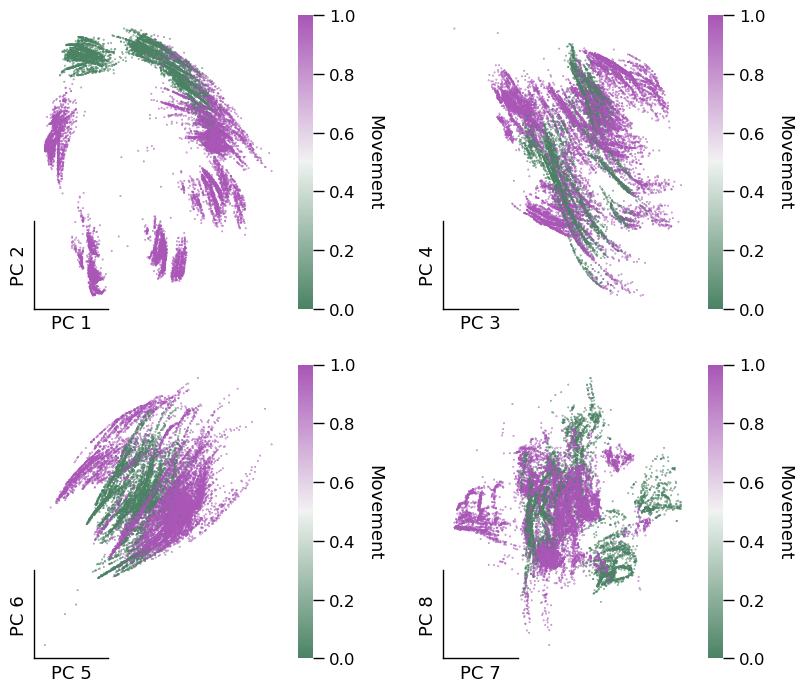

In [60]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(7 * scale, 6 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :],
        pc_activities.T[k+1, :],
        s=0.1,
        c=traj_data['action'],
        cmap=sns.diverging_palette(145, 300, s=60, as_cmap=True),
        alpha=1,
    )

    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Movement', rotation=270, labelpad=20)

fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)

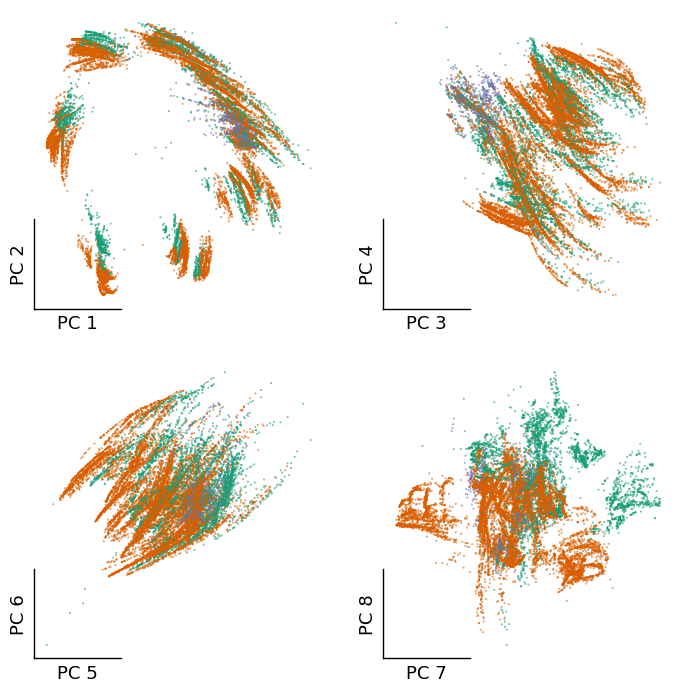

In [67]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(6 * scale, 6 * scale))

def patch_reward_param_to_color(p):       
    if p == 0:
        return color_unrewarded
    elif p == 10:
        return color_low_reward
    elif p == 30:
        return color_high_reward
    else:
        return 'gray'

color_mapper = np.vectorize(patch_reward_param_to_color)

mask = traj_data['agent_in_patch'] > 0

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][mask],
        pc_activities.T[k+1, :][mask],
        s=0.1,
        c=color_mapper(traj_data['patch_reward_param'][mask]),
        alpha=1,
    )

fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)

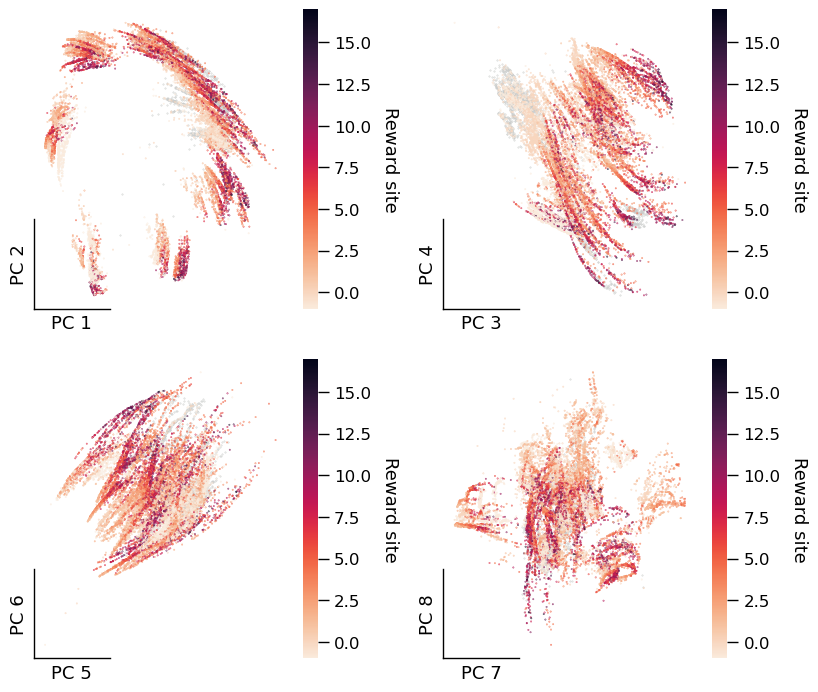

In [53]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(7 * scale, 6 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] <= 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] <= 0],
        s=0.11,
        c='#cacccb',
        alpha=1,
        zorder=-1,
    )

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] > 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] > 0],
        s=0.1,
        c=traj_data['reward_site_idx'][traj_data['agent_in_patch'] > 0],
        cmap=sns.color_palette('rocket_r', as_cmap=True),
        alpha=1,
    )

    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Reward site', rotation=270, labelpad=20)

fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)

/tmp/ipykernel_3078152/992472890.py:18: RuntimeWarning: invalid value encountered in divide
  reward_probs = 0.8 * np.exp(-traj_data['rewards_seen_in_patch'][traj_data['agent_in_patch'] > 0] / reward_params)


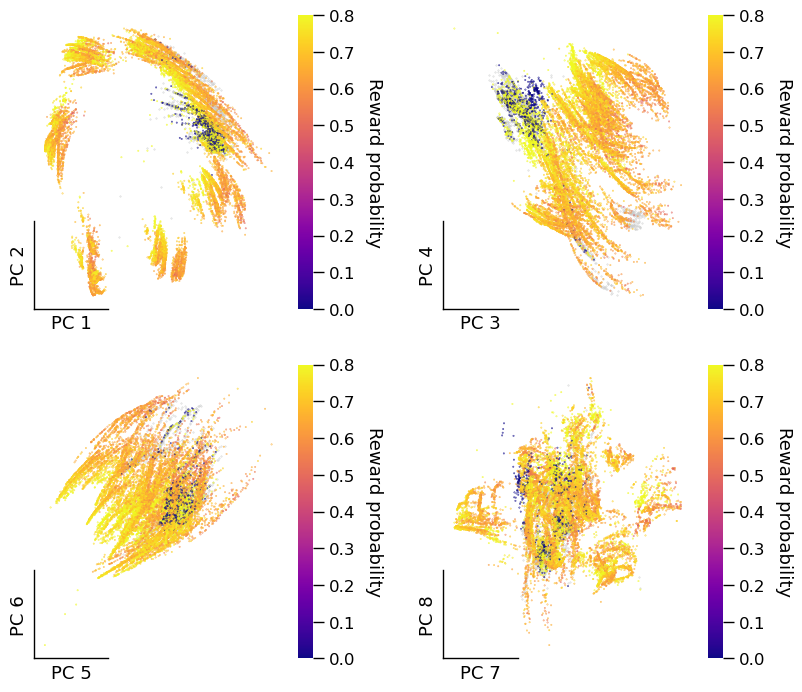

In [54]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(7 * scale, 6 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] <= 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] <= 0],
        s=0.1,
        c='#cacccb',
        alpha=1,
        zorder=-1,
    )

    reward_params_for_odors = np.array([0, 10, 30])
    reward_params = reward_params_for_odors[traj_data['current_patch_num'][traj_data['agent_in_patch'] > 0].astype(int)]
    reward_probs = 0.8 * np.exp(-traj_data['rewards_seen_in_patch'][traj_data['agent_in_patch'] > 0] / reward_params)
    reward_probs[traj_data['current_patch_num'][traj_data['agent_in_patch'] > 0] == 0] = 0

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] > 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] > 0],
        s=0.1,
        c=reward_probs,
        cmap=sns.color_palette('plasma', as_cmap=True),
        alpha=1,
    )

    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Reward probability', rotation=270, labelpad=20)

fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)

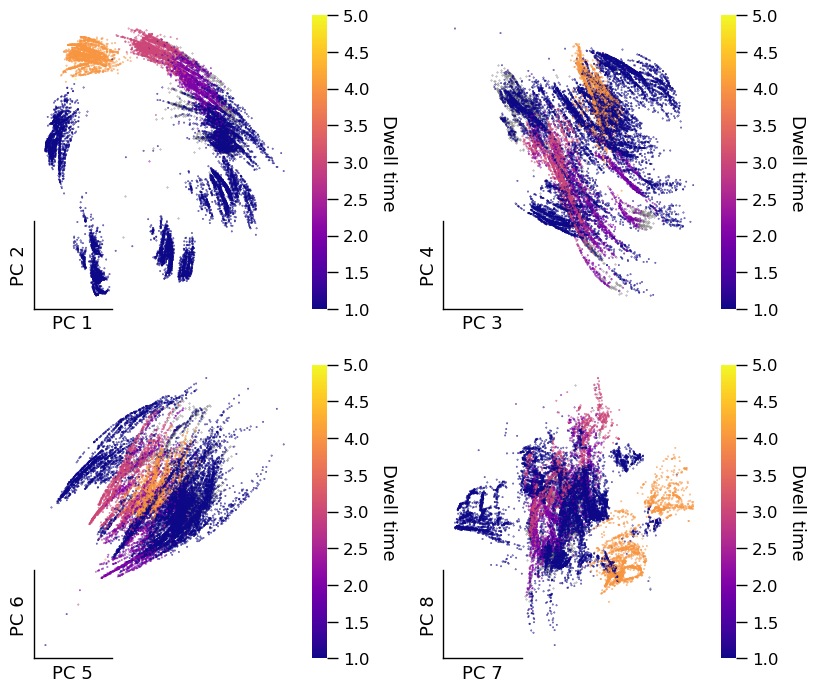

In [56]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(7 * scale, 6 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] <= 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] <= 0],
        s=0.1,
        c='grey',
        alpha=1,
    )

    cbar = axs[k_x, k_y].scatter(
        pc_activities.T[k, :][traj_data['agent_in_patch'] > 0],
        pc_activities.T[k+1, :][traj_data['agent_in_patch'] > 0],
        s=0.1,
        c=traj_data['dwell_time'][traj_data['agent_in_patch'] > 0],
        cmap='plasma',
        alpha=1,
    )

    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Dwell time', rotation=270, labelpad=20)

fig.tight_layout()
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
# fig.tight_layout()
format_pc_plot(axs)


### Compute q values (kinetic energy)

In [19]:
q = 0.5 * np.sum(np.square(hidden[..., 1:] - hidden[..., :-1]), axis=0)

#### For odor 1, color states by q value.

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


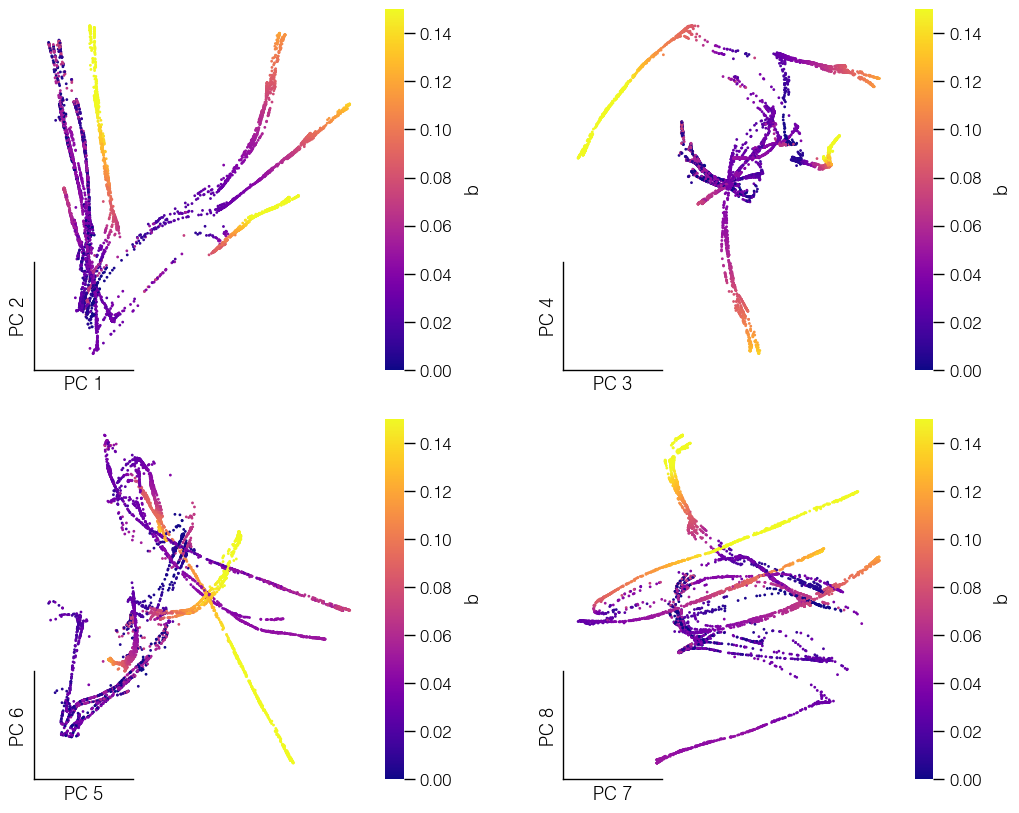

In [21]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_1_mask = logical_and(session_data['current_patch_num'][:-1] == 1, session_data['agent_in_patch'][:-1])
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_1_mask],
        pc_activities[k+1, env_idx, :-1][odor_1_mask],
        s=1,
        c=q[env_idx][odor_1_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.15,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

#### For odor 2, color states by q value.

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


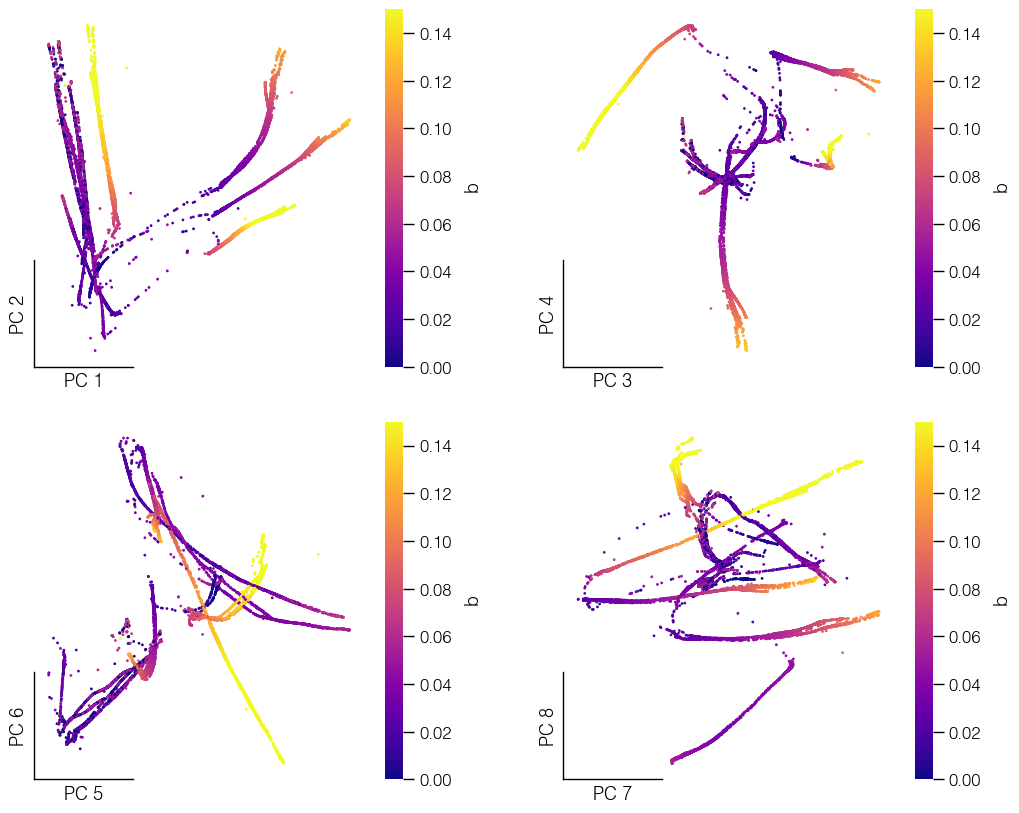

In [22]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_2_mask = logical_and(session_data['current_patch_num'][:-1] == 2, session_data['agent_in_patch'][:-1])
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_2_mask],
        pc_activities[k+1, env_idx, :-1][odor_2_mask],
        s=1,
        c=q[env_idx][odor_2_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.15,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

### Only show states where agent is rewarded

Compute for odor 1

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


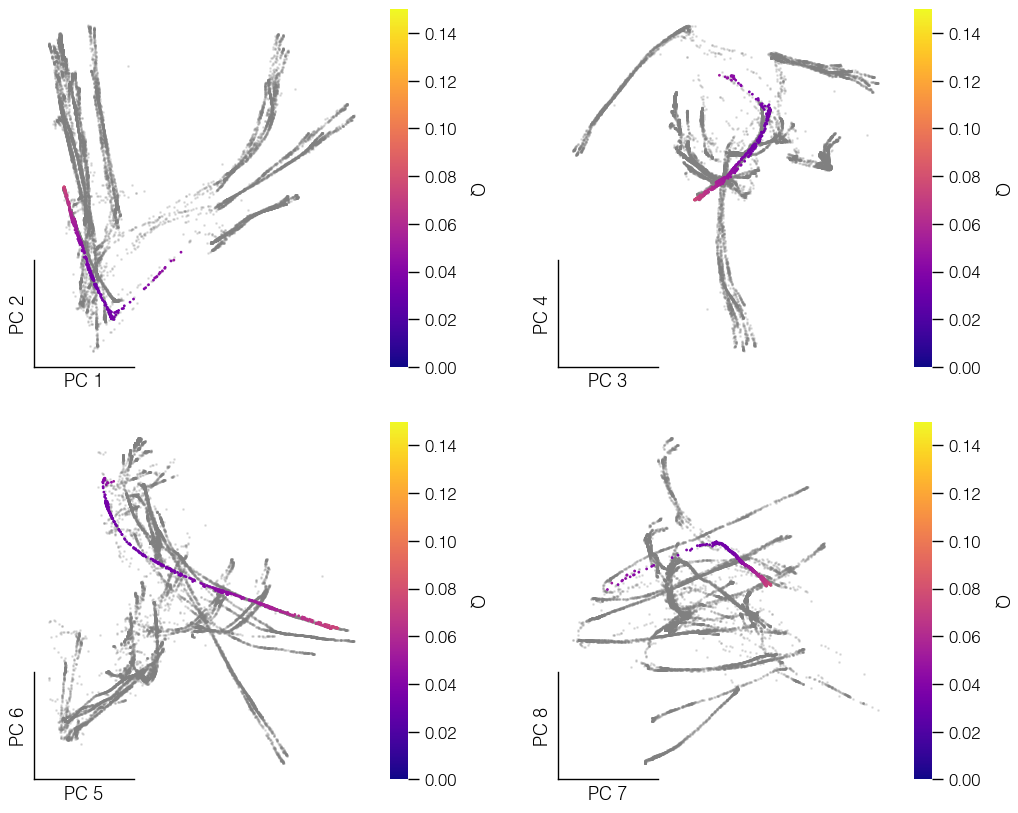

In [23]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_1_mask = logical_and(session_data['current_patch_num'][:-1] == 1, np.roll(session_data['reward'][:-1], 0) > 0)

    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][~odor_1_mask],
        pc_activities[k+1, env_idx, :-1][~odor_1_mask],
        s=1,
        color='grey',
        alpha=0.2
    )
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_1_mask],
        pc_activities[k+1, env_idx, :-1][odor_1_mask],
        s=1,
        c=q[env_idx][odor_1_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.15,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

For odor 2

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


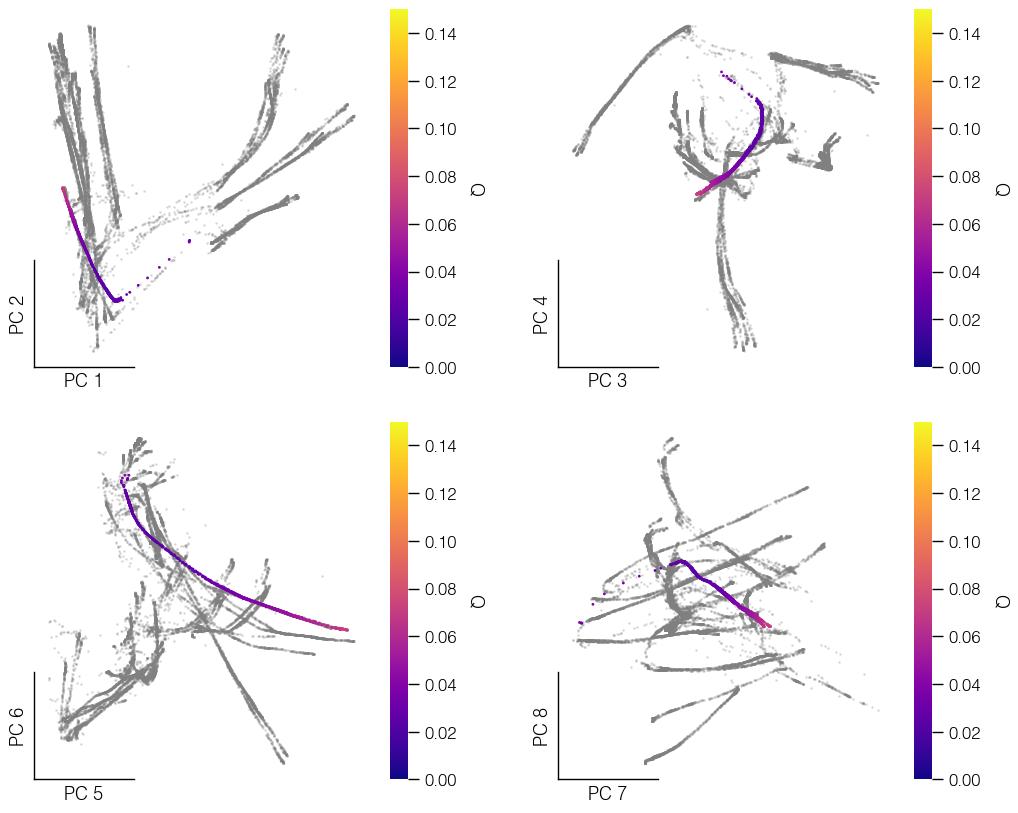

In [24]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_2_mask = logical_and(session_data['current_patch_num'][:-1] == 2, np.roll(session_data['reward'][:-1], 0) > 0)

    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][~odor_2_mask],
        pc_activities[k+1, env_idx, :-1][~odor_2_mask],
        s=1,
        color='grey',
        alpha=0.2
    )
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_2_mask],
        pc_activities[k+1, env_idx, :-1][odor_2_mask],
        s=1,
        c=q[env_idx][odor_2_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.15,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

### Compute component of q that is just along acc. reward direction

In [25]:
delta_h = hidden[..., 1:] - hidden[..., :-1]
rep_direction_norm = rep_direction / np.linalg.norm(rep_direction)
delta_h_proj_rep_direction = np.tensordot(delta_h, rep_direction_norm, ([0], [0]))
delta_h_proj_rep_direction.shape

q_along_rep_direction = 0.5 * np.square(delta_h_proj_rep_direction)

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


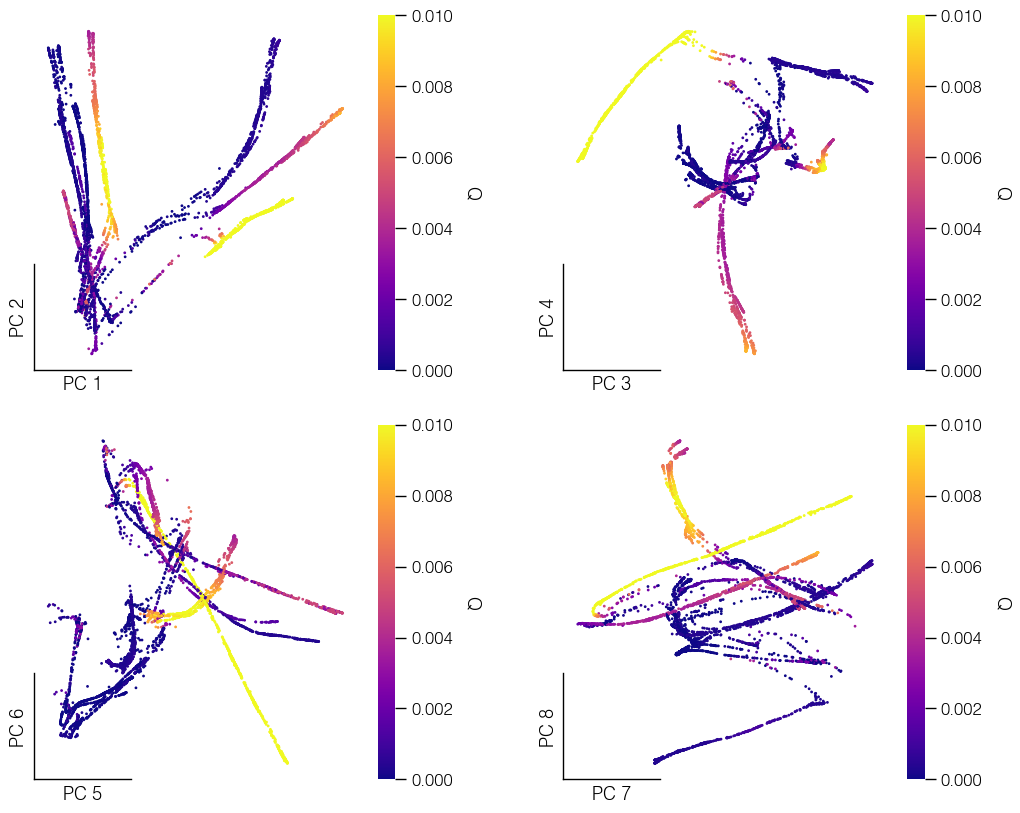

In [26]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_1_mask = logical_and(session_data['current_patch_num'][:-1] == 1, session_data['agent_in_patch'][:-1])
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_1_mask],
        pc_activities[k+1, env_idx, :-1][odor_1_mask],
        s=1,
        c=q_along_rep_direction[env_idx][odor_1_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.01,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


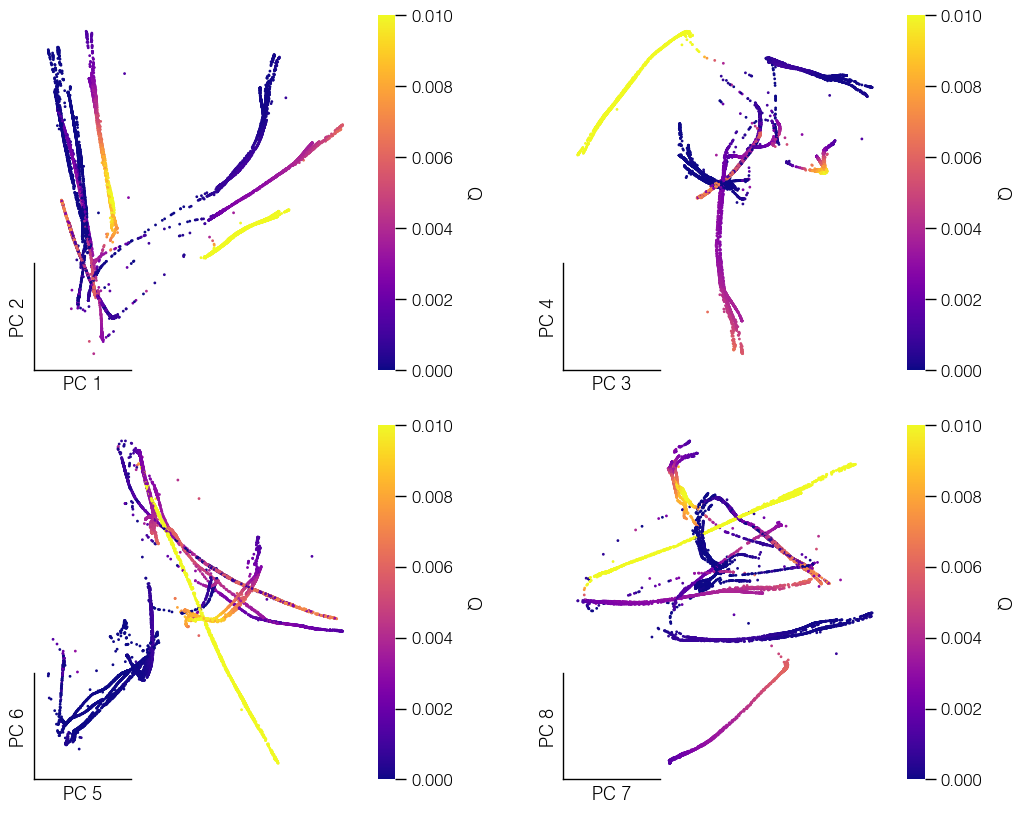

In [27]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_2_mask = logical_and(session_data['current_patch_num'][:-1] == 2, session_data['agent_in_patch'][:-1])
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_2_mask],
        pc_activities[k+1, env_idx, :-1][odor_2_mask],
        s=1,
        c=q_along_rep_direction[env_idx][odor_2_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.01,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

### Show same projection of q along acc. reward direction, but remove states where agent is rewarded

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


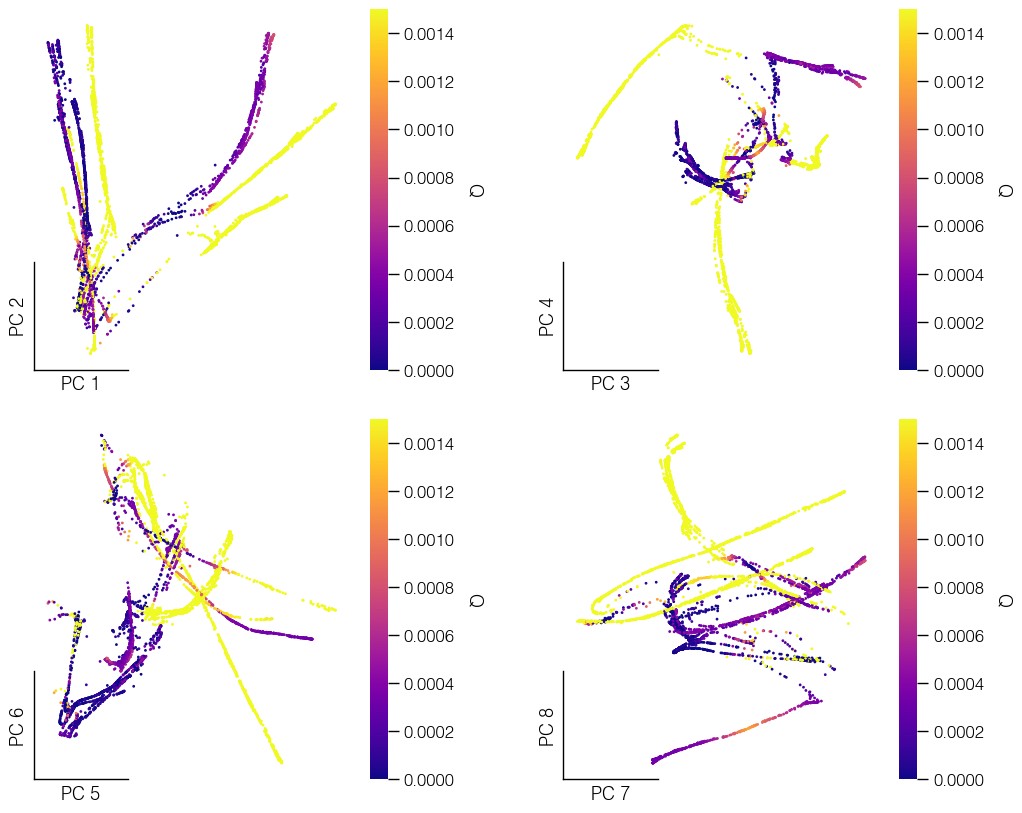

In [28]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_1_mask = logical_and(session_data['current_patch_num'][:-1] == 1, session_data['agent_in_patch'][:-1], session_data['reward'][:-1] == 0)
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_1_mask],
        pc_activities[k+1, env_idx, :-1][odor_1_mask],
        s=1,
        c=q_along_rep_direction[env_idx][odor_1_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.0015,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


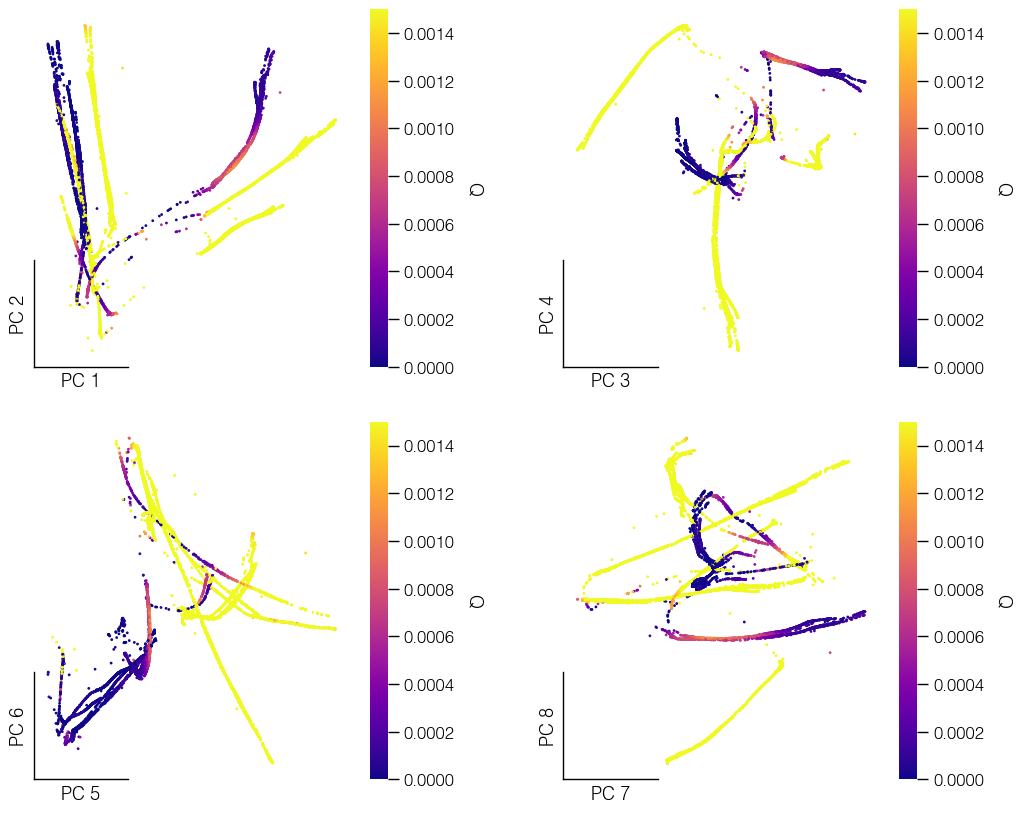

In [29]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_2_mask = logical_and(session_data['current_patch_num'][:-1] == 2, session_data['agent_in_patch'][:-1], session_data['reward'][:-1] == 0)
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_2_mask],
        pc_activities[k+1, env_idx, :-1][odor_2_mask],
        s=1,
        c=q_along_rep_direction[env_idx][odor_2_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.0015,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('Q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

### Highlight rewarded states, color by q along acc. reward direction

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


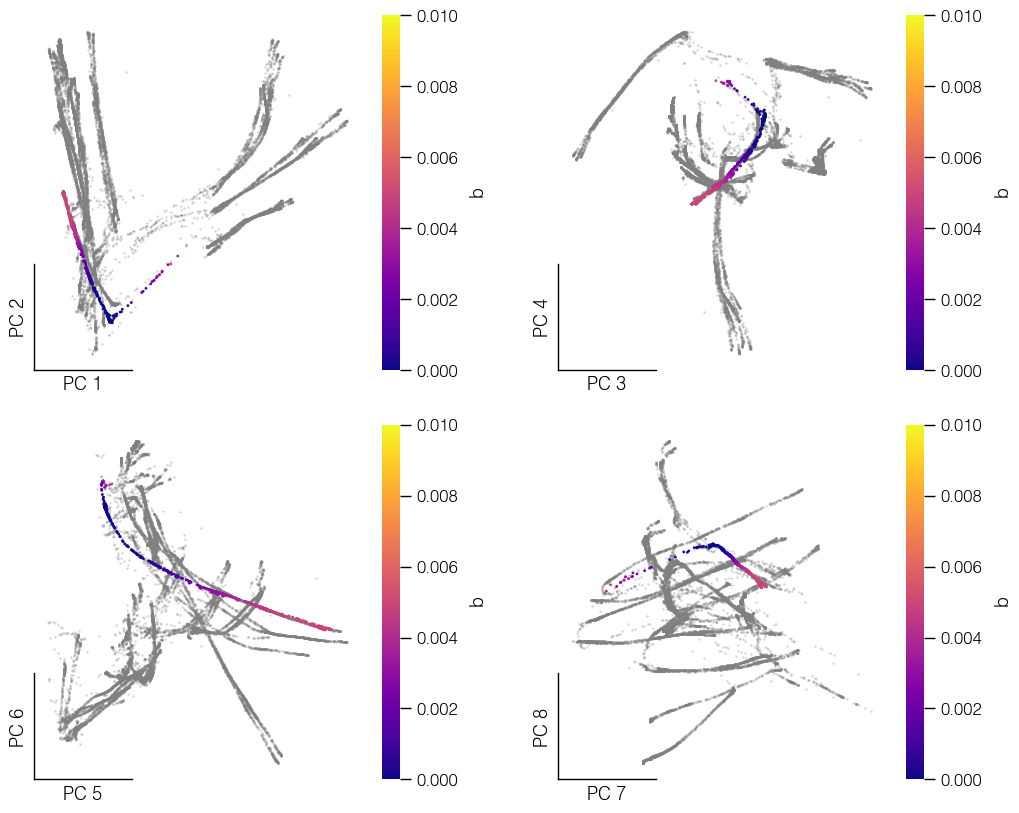

In [33]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_1_mask = logical_and(session_data['current_patch_num'][:-1] == 1, np.roll(session_data['reward'][:-1], 0) > 0)

    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][~odor_1_mask],
        pc_activities[k+1, env_idx, :-1][~odor_1_mask],
        s=1,
        color='grey',
        alpha=0.2
    )
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_1_mask],
        pc_activities[k+1, env_idx, :-1][odor_1_mask],
        s=1,
        c=q_along_rep_direction[env_idx][odor_1_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.01,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)

Axes(0.424432,0.53;0.0528409x0.35)
Axes(0.847159,0.53;0.0528409x0.35)
Axes(0.424432,0.11;0.0528409x0.35)
Axes(0.847159,0.11;0.0528409x0.35)
[<Axes: > <Axes: > <Axes: > <Axes: >]
[<Axes: xlabel='PC 1', ylabel='PC 2'>, <Axes: xlabel='PC 3', ylabel='PC 4'>, <Axes: xlabel='PC 5', ylabel='PC 6'>, <Axes: xlabel='PC 7', ylabel='PC 8'>]


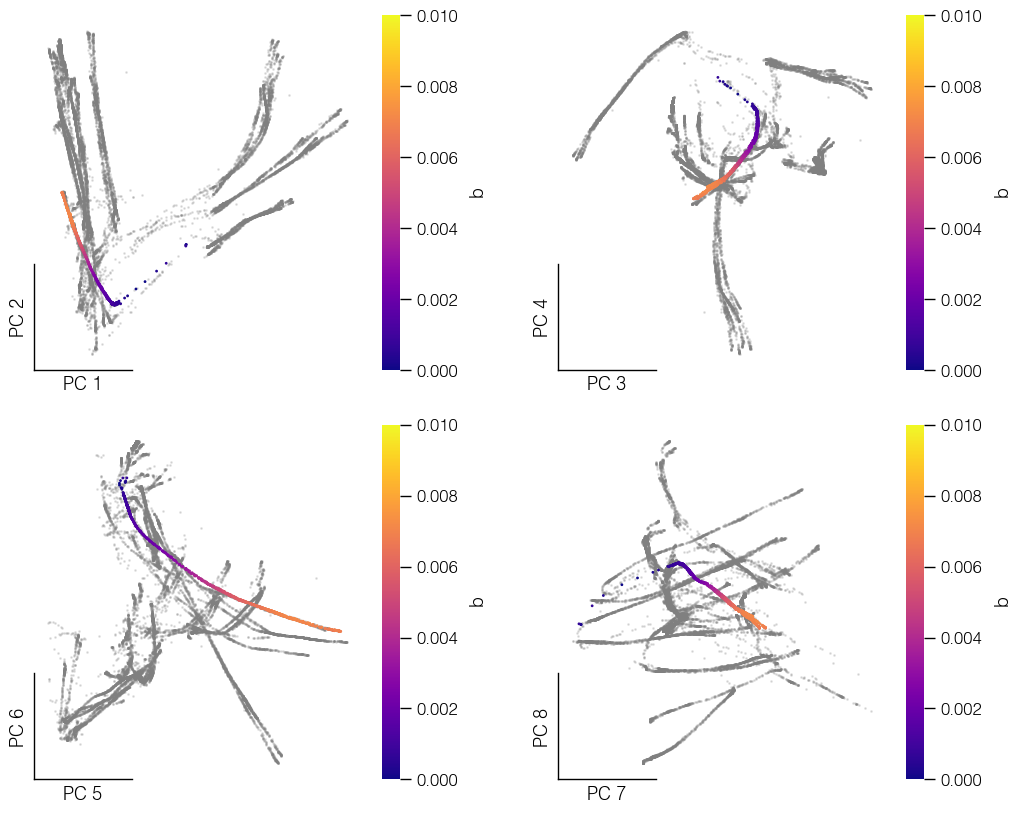

In [32]:
scale = 1.2
fig, axs = plt.subplots(2, 2, figsize=(9 * scale, 7 * scale))

for k in np.arange(0, 8, 2):
    k_x, k_y = int(k/4), int(k/2) % 2

    odor_2_mask = logical_and(session_data['current_patch_num'][:-1] == 2, np.roll(session_data['reward'][:-1], 0) > 0)

    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][~odor_2_mask],
        pc_activities[k+1, env_idx, :-1][~odor_2_mask],
        s=1,
        color='grey',
        alpha=0.2
    )
    
    cbar = axs[k_x, k_y].scatter(
        pc_activities[k, env_idx, :-1][odor_2_mask],
        pc_activities[k+1, env_idx, :-1][odor_2_mask],
        s=1,
        c=q_along_rep_direction[env_idx][odor_2_mask],
        cmap='plasma',
        vmin=0,
        vmax=0.01,
    )
    cbar_ax = fig.colorbar(cbar)
    format_plot(cbar_ax.ax, rightspine=False, leftspine=False, topspine=False, bottomspine=False)
    cbar_ax.outline.set_visible(False)
    cbar_ax.set_label('q', rotation=270, labelpad=20)
# axs[0, 0].set_title('Activity colored by rewards seen in patch')
fig.tight_layout()
format_pc_plot(axs)